In [1]:
import pandas as pd

df = pd.read_csv('train.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

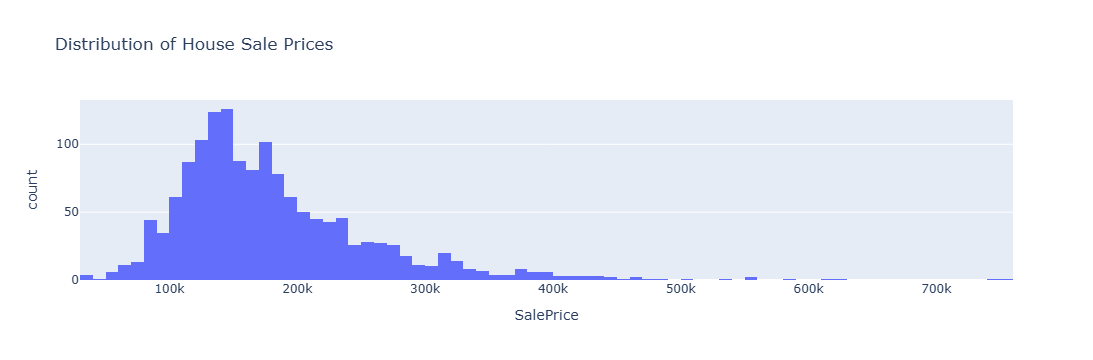

In [3]:
import plotly.express as px

fig = px.histogram(df, x='SalePrice', title='Distribution of House Sale Prices')
fig.show()

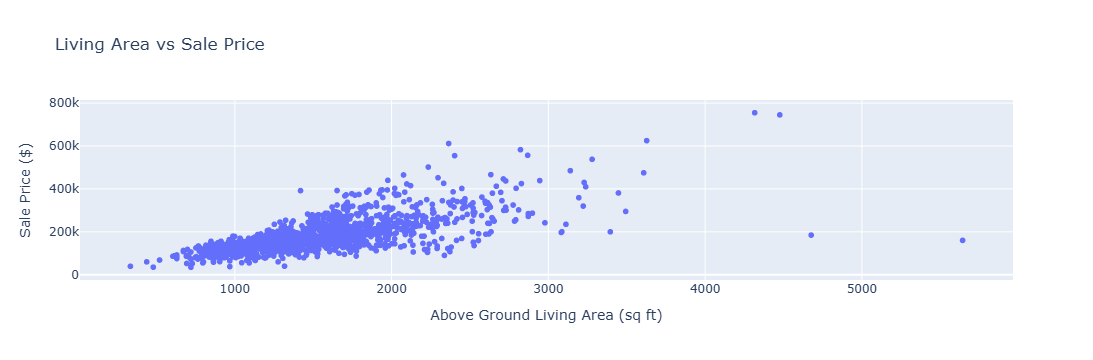

In [4]:
fig = px.scatter(
    df, 
    x='GrLivArea', 
    y='SalePrice',
    title='Living Area vs Sale Price',
    labels={'GrLivArea': 'Above Ground Living Area (sq ft)', 'SalePrice': 'Sale Price ($)'}
)
fig.show()

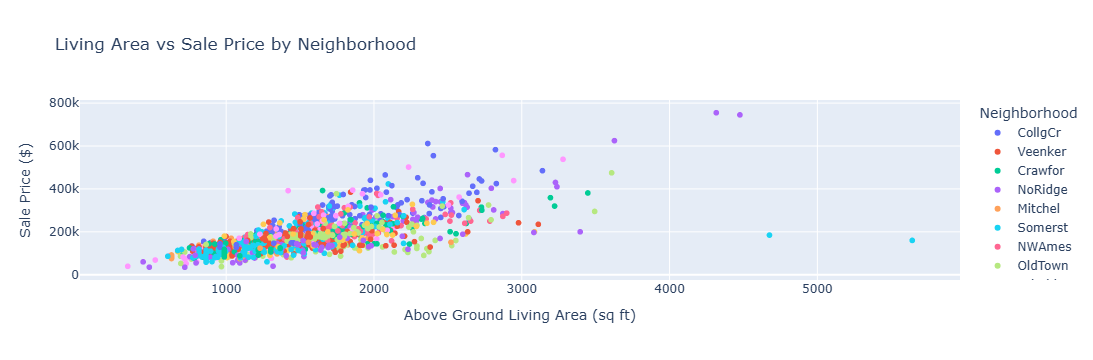

In [5]:
fig = px.scatter(
    df,
    x='GrLivArea',
    y='SalePrice',
    color='Neighborhood',
    title='Living Area vs Sale Price by Neighborhood',
    labels={'GrLivArea': 'Above Ground Living Area (sq ft)', 'SalePrice': 'Sale Price ($)'}
)
fig.show()

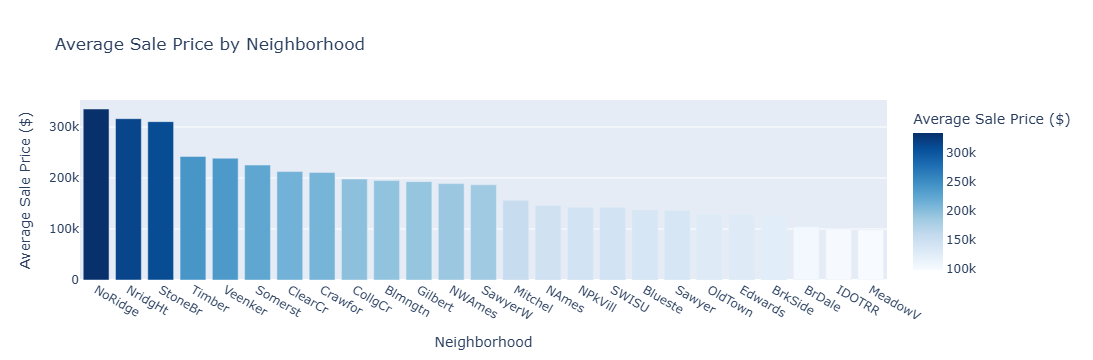

In [6]:
avg_price = df.groupby('Neighborhood')['SalePrice'].mean().reset_index()
avg_price = avg_price.sort_values('SalePrice', ascending=False)

fig = px.bar(
    avg_price,
    x='Neighborhood',
    y='SalePrice',
    title='Average Sale Price by Neighborhood',
    labels={'SalePrice': 'Average Sale Price ($)'},
    color='SalePrice',
    color_continuous_scale='Blues'
)
fig.show()

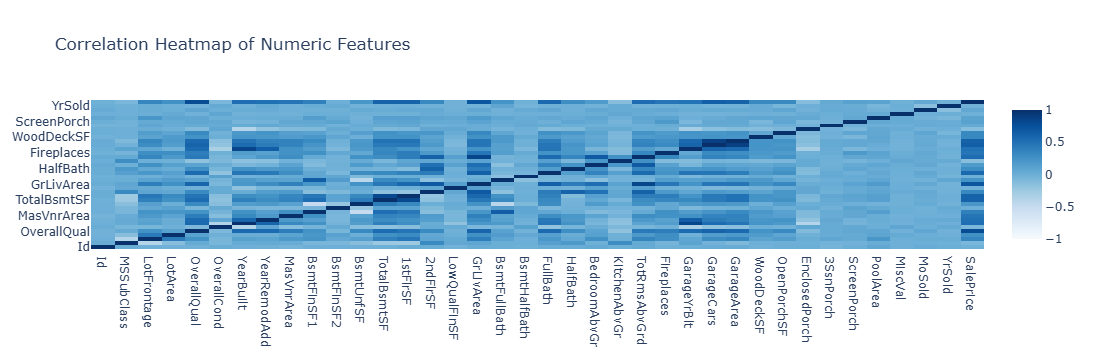

In [7]:
import plotly.graph_objects as go

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr().round(2)

fig = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=corr.columns,
    y=corr.columns,
    colorscale='Blues',
    zmin=-1,
    zmax=1
))

fig.update_layout(title='Correlation Heatmap of Numeric Features')
fig.show()

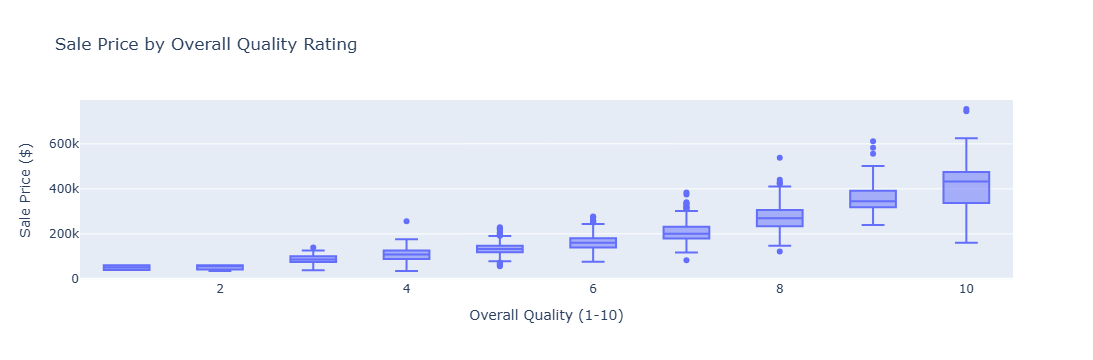

In [9]:
fig = px.box(
    df,
    x='OverallQual',
    y='SalePrice',
    title='Sale Price by Overall Quality Rating',
    labels={'OverallQual': 'Overall Quality (1-10)', 'SalePrice': 'Sale Price ($)'}
)
fig.show()